Example folder: G:\Data Sets\Centrifugal Pump\Centrifugal Pump 3.5 bar\IF_3.5
Number of .mat files: 359
First 5 files: ['2020-04-28 16-35-39.mat', '2020-04-28 16-35-40.mat', '2020-04-28 16-35-41.mat', '2020-04-28 16-35-42.mat', '2020-04-28 16-35-43.mat']

Loaded file: G:\Data Sets\Centrifugal Pump\Centrifugal Pump 3.5 bar\IF_3.5\2020-04-28 16-35-39.mat
fs: 25600.0
signal shape: (3, 25600)


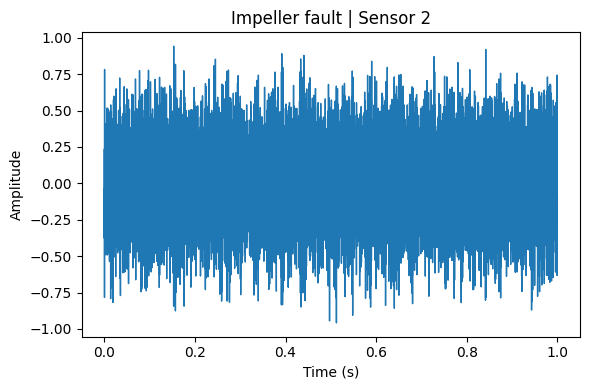

In [6]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# =========================================================
# STEP 1: Dataset path + loader + single file sanity check
# =========================================================

BASE_PATH = r"G:\Data Sets\Centrifugal Pump\Centrifugal Pump 3.5 bar"

# Folder names and readable class names
CLASS_FOLDERS = {
    "N_3.5":   "Normal",
    "IF_3.5":  "Impeller fault",
    "MSS_3.5": "Mechanical seal scratch",
    "MSH_3.5": "Mechanical seal hole",
}

def list_mat_files(folder_path):
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(".mat")]
    files.sort()
    return files

def load_one_mat(mat_path):
    d = scipy.io.loadmat(mat_path)

    if "signal" not in d or "fs" not in d:
        raise KeyError(
            f"Missing 'signal' or 'fs' in: {mat_path}\n"
            f"Keys found: {list(d.keys())}"
        )

    signal = np.array(d["signal"], dtype=np.float64)
    fs = float(np.squeeze(d["fs"]))

    if signal.ndim != 2:
        raise ValueError(f"'signal' must be 2D, got {signal.shape} in {mat_path}")

    # Expected (3, 25600)
    return signal, fs

# -----------------------------
# Sanity check: load one example
# -----------------------------
example_class = "IF_3.5"     # change to test other classes
sensor_id = 1               # 0,1,2 -> sensor 2 is index 1

example_folder = os.path.join(BASE_PATH, example_class)
mat_files = list_mat_files(example_folder)

print("Example folder:", example_folder)
print("Number of .mat files:", len(mat_files))
print("First 5 files:", mat_files[:5])

example_mat = os.path.join(example_folder, mat_files[0])
signal, fs = load_one_mat(example_mat)

print("\nLoaded file:", example_mat)
print("fs:", fs)
print("signal shape:", signal.shape)

# Plot selected sensor signal
x = signal[sensor_id, :]
x = x - np.mean(x)
t = np.arange(len(x)) / fs

plt.figure(figsize=(6, 4))
plt.plot(t, x, linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"{CLASS_FOLDERS[example_class]} | Sensor {sensor_id+1}")
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from scipy.signal import welch

# =========================================================
# STEP 2A: Physics-guided window selection
# =========================================================

def band_energy_ratio(w, fs, f_low=500, f_high=5000, nperseg=1024):
    """
    Ratio of band-limited energy to total energy using Welch PSD
    """
    w = w - np.mean(w)
    f, Pxx = welch(w, fs=fs, nperseg=min(nperseg, len(w)))
    total_energy = np.trapz(Pxx, f) + 1e-12

    mask = (f >= f_low) & (f <= f_high)
    band_energy = np.trapz(Pxx[mask], f[mask]) + 1e-12

    return band_energy / total_energy

def extract_top_physics_windows(
    x, fs,
    win_sec=0.25,
    hop_sec=0.05,
    top_k=3,
    f_low=500,
    f_high=5000,
    alpha=0.5,
    beta=0.3,
    gamma=0.2
):
    """
    Physics-Guided Window Scoring (PGWS)
    """
    L = int(win_sec * fs)
    H = int(hop_sec * fs)

    starts = list(range(0, len(x) - L + 1, H))

    energies, kurts, bands = [], [], []

    for s in starts:
        w = x[s:s+L] - np.mean(x[s:s+L])

        energies.append(np.sum(w**2))
        kurts.append(kurtosis(w, fisher=False))
        bands.append(band_energy_ratio(w, fs, f_low, f_high))

    energies = np.array(energies)
    kurts = np.array(kurts)
    bands = np.array(bands)

    # Normalize metrics
    def norm(a):
        return (a - a.min()) / (a.max() - a.min() + 1e-12)

    E_n = norm(energies)
    K_n = norm(kurts)
    B_n = norm(bands)

    scores = alpha * E_n + beta * K_n + gamma * B_n

    order = np.argsort(scores)[::-1][:top_k]

    top_windows = []
    top_info = []

    for idx in order:
        s = starts[idx]
        e = s + L
        top_windows.append(x[s:e] - np.mean(x[s:e]))
        top_info.append((s, e, scores[idx], energies[idx], kurts[idx], bands[idx]))

    return top_windows, top_info


Selected windows:
start  end   score   energy   kurtosis   band_ratio
  8960  15360 0.9123 4.99e+02 2.73 0.9407
  6400  12800 0.8349 4.90e+02 2.74 0.9399
  5120  11520 0.8015 4.92e+02 2.75 0.9353


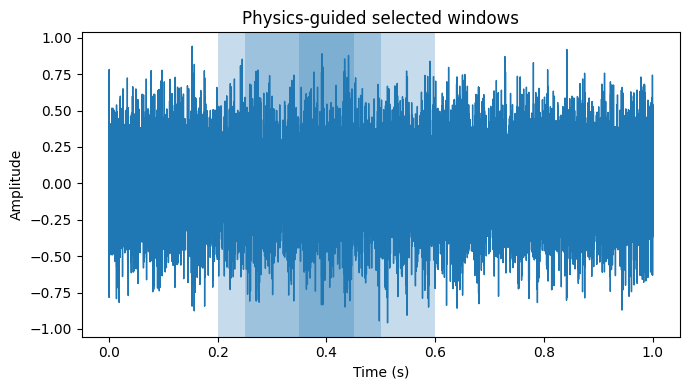

In [8]:
# =========================================================
# STEP 2B: Apply PGWS to example signal
# =========================================================

win_sec = 0.25
hop_sec = 0.05
top_k = 3

top_windows, top_info = extract_top_physics_windows(
    x, fs,
    win_sec=win_sec,
    hop_sec=hop_sec,
    top_k=top_k
)

print("Selected windows:")
print("start  end   score   energy   kurtosis   band_ratio")
for info in top_info:
    print(f"{info[0]:6d} {info[1]:6d} {info[2]:.4f} {info[3]:.2e} {info[4]:.2f} {info[5]:.4f}")

# Plot signal and highlight selected windows
t = np.arange(len(x)) / fs

plt.figure(figsize=(7, 4))
plt.plot(t, x, linewidth=1)
for (s, e, *_ ) in top_info:
    plt.axvspan(s/fs, e/fs, alpha=0.25)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Physics-guided selected windows")
plt.tight_layout()
plt.show()


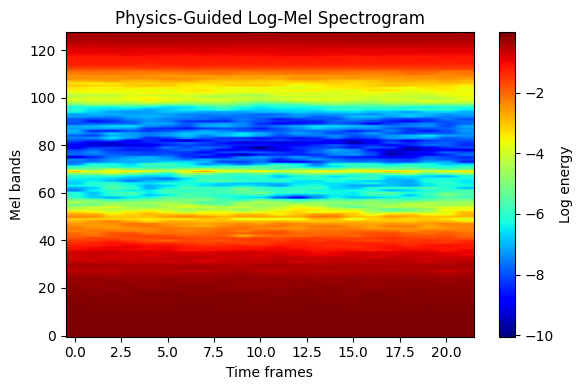

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# =========================================================
# STEP 3A: Physics-aware Log-Mel Spectrogram
# =========================================================

def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)

def mel_filterbank(fs, n_fft, n_mels=128, fmin=0, fmax=None):
    if fmax is None:
        fmax = fs / 2

    freqs = np.linspace(0, fs / 2, n_fft // 2 + 1)

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    bins = np.floor((n_fft + 1) * hz_points / fs).astype(int)

    fb = np.zeros((n_mels, len(freqs)))

    for m in range(1, n_mels + 1):
        l, c, r = bins[m - 1], bins[m], bins[m + 1]
        for k in range(l, c):
            fb[m - 1, k] = (k - l) / (c - l + 1e-12)
        for k in range(c, r):
            fb[m - 1, k] = (r - k) / (r - c + 1e-12)

    return fb

def physics_weight_mask(n_mels, focus_ratio=0.6):
    """
    Simple physics bias:
    emphasize mid-to-high Mel bands where pump faults dominate
    """
    idx = np.arange(n_mels)
    center = int(n_mels * focus_ratio)
    sigma = n_mels * 0.15
    w = np.exp(-0.5 * ((idx - center) / sigma) ** 2)
    return w / w.max()

def physics_guided_mel(x, fs, n_fft=1024, hop=256, n_mels=128):
    f, t, Z = stft(
        x, fs=fs, window="hann",
        nperseg=n_fft,
        noverlap=n_fft-hop,
        nfft=n_fft,
        padded=False, boundary=None
    )

    S = np.abs(Z) ** 2

    mel_fb = mel_filterbank(fs, n_fft, n_mels=n_mels)
    mel = np.dot(mel_fb, S)
    mel = np.log(mel + 1e-10)

    # Physics weighting
    W = physics_weight_mask(n_mels)
    mel_pg = mel * W[:, None]

    return mel_pg

# -----------------------------
# Test on top physics window
# -----------------------------
x_win = top_windows[0]

mel_pg = physics_guided_mel(x_win, fs)

plt.figure(figsize=(6, 4))
plt.imshow(
    mel_pg,
    aspect="auto",
    origin="lower",
    cmap="jet"
)
plt.title("Physics-Guided Log-Mel Spectrogram")
plt.xlabel("Time frames")
plt.ylabel("Mel bands")
plt.colorbar(label="Log energy")
plt.tight_layout()
plt.show()


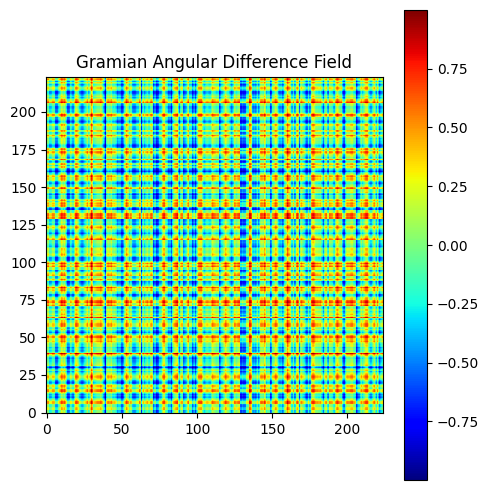

In [10]:
# =========================================================
# STEP 3B: GADF (same as before)
# =========================================================

def gadf_image(x, N=224):
    x = x - np.mean(x)
    xmin, xmax = np.min(x), np.max(x)
    x = (2*x - (xmax + xmin)) / (xmax - xmin + 1e-12)
    x = np.clip(x, -1, 1)

    idx = np.linspace(0, len(x)-1, N).astype(int)
    x = x[idx]

    phi = np.arccos(x)
    return np.sin(phi[:, None] - phi[None, :])

gadf = gadf_image(x_win)

plt.figure(figsize=(5, 5))
plt.imshow(gadf, cmap="jet", origin="lower")
plt.title("Gramian Angular Difference Field")
plt.colorbar()
plt.tight_layout()
plt.show()


In [11]:
from scipy.ndimage import zoom

# =========================================================
# STEP 4A: Resize + normalize
# =========================================================

def zscore(img):
    return (img - img.mean()) / (img.std() + 1e-8)

# Resize Mel to 224x224
mel = mel_pg
mel = zoom(mel, (224 / mel.shape[0], 224 / mel.shape[1]), order=1)

mel = zscore(mel)
gadf_n = zscore(gadf)

print("Mel shape:", mel.shape)
print("GADF shape:", gadf_n.shape)


Mel shape: (224, 224)
GADF shape: (224, 224)


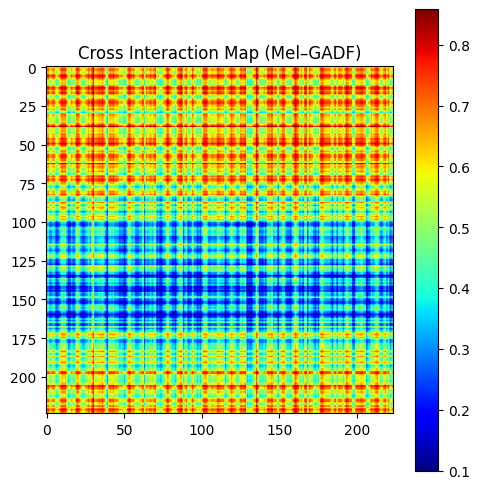

In [12]:
# =========================================================
# STEP 4B: Cross Interaction Map (CIM)
# =========================================================

def cross_interaction_map(mel, gadf, wm=0.5, wg=0.5):
    """
    Learnable fusion proxy (weights will be learned later in CNN)
    """
    x = wm * mel + wg * gadf
    return 1 / (1 + np.exp(-x))  # sigmoid

cim = cross_interaction_map(mel, gadf_n)

plt.figure(figsize=(5, 5))
plt.imshow(cim, cmap="jet")
plt.title("Cross Interaction Map (Mel–GADF)")
plt.colorbar()
plt.tight_layout()
plt.show()


Fused image shape: (224, 224, 3)


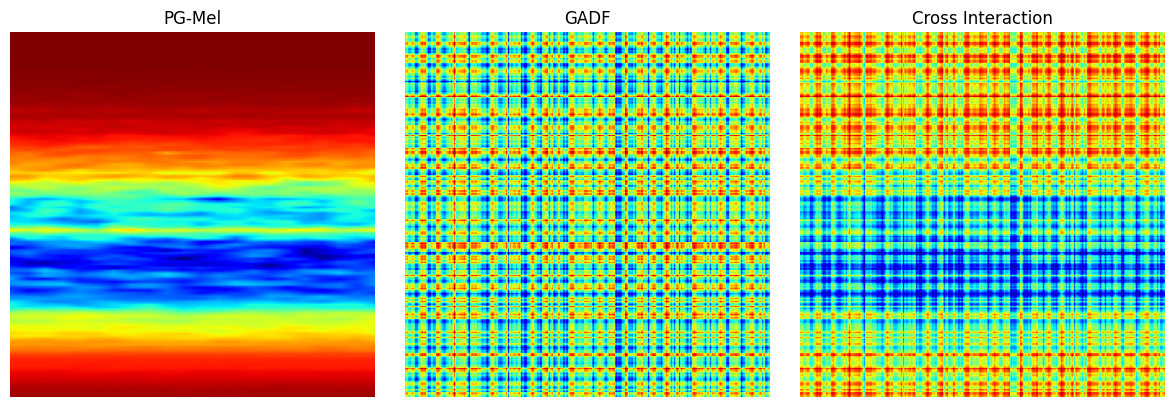

In [13]:
# =========================================================
# STEP 4C: Final fused image
# =========================================================

fused_img = np.stack([mel, gadf_n, cim], axis=-1)

print("Fused image shape:", fused_img.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(mel, cmap="jet")
plt.title("PG-Mel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gadf_n, cmap="jet")
plt.title("GADF")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cim, cmap="jet")
plt.title("Cross Interaction")
plt.axis("off")

plt.tight_layout()
plt.show()


In [14]:
import os
import numpy as np
import scipy.io
from scipy.signal import stft, welch
from scipy.stats import kurtosis
from scipy.ndimage import zoom

# -----------------------------
# Utility functions
# -----------------------------
def zscore(x):
    return (x - x.mean()) / (x.std() + 1e-8)

# -----------------------------
# Physics-guided window selection
# -----------------------------
def band_energy_ratio(w, fs, f_low=500, f_high=5000):
    f, Pxx = welch(w, fs=fs, nperseg=min(1024, len(w)))
    total = np.trapz(Pxx, f) + 1e-12
    mask = (f >= f_low) & (f <= f_high)
    band = np.trapz(Pxx[mask], f[mask]) + 1e-12
    return band / total

def extract_pgws_windows(x, fs, win_sec, hop_sec, top_k):
    L = int(win_sec * fs)
    H = int(hop_sec * fs)
    starts = range(0, len(x) - L + 1, H)

    scores = []
    windows = []

    for s in starts:
        w = x[s:s+L] - np.mean(x[s:s+L])
        E = np.sum(w**2)
        K = kurtosis(w, fisher=False)
        B = band_energy_ratio(w, fs)
        scores.append(0.5*E + 0.3*K + 0.2*B)
        windows.append(w)

    scores = np.array(scores)
    idx = np.argsort(scores)[::-1][:top_k]

    return [windows[i] for i in idx]

# -----------------------------
# Physics-guided Mel
# -----------------------------
def hz_to_mel(f): return 2595*np.log10(1 + f/700)
def mel_to_hz(m): return 700*(10**(m/2595) - 1)

def mel_filterbank(fs, n_fft, n_mels):
    freqs = np.linspace(0, fs/2, n_fft//2 + 1)
    mel_pts = np.linspace(hz_to_mel(0), hz_to_mel(fs/2), n_mels+2)
    hz_pts = mel_to_hz(mel_pts)
    bins = np.floor((n_fft+1)*hz_pts/fs).astype(int)

    fb = np.zeros((n_mels, len(freqs)))
    for m in range(1, n_mels+1):
        l,c,r = bins[m-1], bins[m], bins[m+1]
        fb[m-1, l:c] = (np.arange(l,c)-l)/(c-l+1e-8)
        fb[m-1, c:r] = (r-np.arange(c,r))/(r-c+1e-8)
    return fb

def physics_guided_mel(x, fs, n_fft=1024, hop=256, n_mels=128):
    f,t,Z = stft(x, fs=fs, window='hann',
                 nperseg=n_fft, noverlap=n_fft-hop,
                 padded=False, boundary=None)
    S = np.abs(Z)**2
    fb = mel_filterbank(fs, n_fft, n_mels)
    mel = np.log(np.dot(fb, S) + 1e-10)

    # physics weighting
    idx = np.arange(n_mels)
    center = int(0.6*n_mels)
    w = np.exp(-0.5*((idx-center)/(0.15*n_mels))**2)
    return mel * w[:,None]

# -----------------------------
# GADF
# -----------------------------
def gadf_image(x, N=224):
    x = x - np.mean(x)
    x = (2*x - (x.max()+x.min()))/(x.max()-x.min()+1e-8)
    x = np.clip(x, -1, 1)
    idx = np.linspace(0, len(x)-1, N).astype(int)
    phi = np.arccos(x[idx])
    return np.sin(phi[:,None] - phi[None,:])

# -----------------------------
# Cross Interaction Map
# -----------------------------
def cross_interaction(mel, gadf):
    return 1/(1 + np.exp(-(0.5*mel + 0.5*gadf)))



In [15]:
# =========================================================
# STEP 5B: Dataset generation
# =========================================================

BASE_PATH = r"G:\Data Sets\Centrifugal Pump\Centrifugal Pump 3.5 bar"

CLASS_MAP = {
    "N_3.5": 0,
    "IF_3.5": 1,
    "MSS_3.5": 2,
    "MSH_3.5": 3,
}

sensor_id = 1
win_sec = 0.25
hop_sec = 0.05
top_k = 2

X, y = [], []

for folder, label in CLASS_MAP.items():
    folder_path = os.path.join(BASE_PATH, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".mat")])

    for fname in files:
        d = scipy.io.loadmat(os.path.join(folder_path, fname))
        fs = float(np.squeeze(d["fs"]))
        x = d["signal"][sensor_id]
        x = x - np.mean(x)

        windows = extract_pgws_windows(x, fs, win_sec, hop_sec, top_k)

        for w in windows:
            mel = physics_guided_mel(w, fs)
            mel = zoom(mel, (224/mel.shape[0], 224/mel.shape[1]), order=1)
            mel = zscore(mel)

            gadf = zscore(gadf_image(w))
            cim = cross_interaction(mel, gadf)

            fused = np.stack([mel, gadf, cim], axis=-1)

            X.append(fused.astype(np.float32))
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Final dataset shape:", X.shape)
print("Labels shape:", y.shape)


Final dataset shape: (2838, 224, 224, 3)
Labels shape: (2838,)


In [16]:
from scipy.stats import kurtosis

def physics_features_1d(w, fs, f_low=500, f_high=5000):
    w = w - np.mean(w)

    rms = np.sqrt(np.mean(w**2) + 1e-12)
    krt = kurtosis(w, fisher=False)
    crest = (np.max(np.abs(w)) + 1e-12) / (rms + 1e-12)
    ber = band_energy_ratio(w, fs, f_low=f_low, f_high=f_high)

    return np.array([rms, krt, crest, ber], dtype=np.float32)


In [17]:
P = []   # physics features

# inside for w in windows:
p = physics_features_1d(w, fs)
P.append(p)


In [18]:
P = np.array(P, dtype=np.float32)
print("Physics features P shape:", P.shape)


Physics features P shape: (1, 4)


In [19]:
import os
import numpy as np
import scipy.io
from scipy.signal import stft, welch
from scipy.stats import kurtosis
from scipy.ndimage import zoom

# -----------------------------
# Utility
# -----------------------------
def zscore(x):
    return (x - x.mean()) / (x.std() + 1e-8)

def band_energy_ratio(w, fs, f_low=500, f_high=5000):
    f, Pxx = welch(w, fs=fs, nperseg=min(1024, len(w)))
    total = np.trapz(Pxx, f) + 1e-12
    mask = (f >= f_low) & (f <= f_high)
    band = np.trapz(Pxx[mask], f[mask]) + 1e-12
    return band / total

def physics_features_1d(w, fs):
    w = w - np.mean(w)
    rms = np.sqrt(np.mean(w**2) + 1e-12)
    krt = kurtosis(w, fisher=False)
    crest = (np.max(np.abs(w)) + 1e-12) / (rms + 1e-12)
    ber = band_energy_ratio(w, fs)
    return np.array([rms, krt, crest, ber], dtype=np.float32)

# -----------------------------
# PGWS
# -----------------------------
def extract_pgws_windows(x, fs, win_sec, hop_sec, top_k):
    L = int(win_sec * fs)
    H = int(hop_sec * fs)
    starts = list(range(0, len(x) - L + 1, H))

    energies, kurts, bands, windows = [], [], [], []
    for s in starts:
        w = x[s:s+L] - np.mean(x[s:s+L])
        energies.append(np.sum(w**2))
        kurts.append(kurtosis(w, fisher=False))
        bands.append(band_energy_ratio(w, fs))
        windows.append(w)

    energies = np.array(energies)
    kurts = np.array(kurts)
    bands = np.array(bands)

    # normalize each
    def norm(a): return (a - a.min()) / (a.max() - a.min() + 1e-12)
    scores = 0.5*norm(energies) + 0.3*norm(kurts) + 0.2*norm(bands)

    idx = np.argsort(scores)[::-1][:top_k]
    return [windows[i] for i in idx]

# -----------------------------
# Mel
# -----------------------------
def hz_to_mel(f): return 2595*np.log10(1 + f/700)
def mel_to_hz(m): return 700*(10**(m/2595) - 1)

def mel_filterbank(fs, n_fft, n_mels):
    freqs = np.linspace(0, fs/2, n_fft//2 + 1)
    mel_pts = np.linspace(hz_to_mel(0), hz_to_mel(fs/2), n_mels+2)
    hz_pts = mel_to_hz(mel_pts)
    bins = np.floor((n_fft+1)*hz_pts/fs).astype(int)

    fb = np.zeros((n_mels, len(freqs)))
    for m in range(1, n_mels+1):
        l,c,r = bins[m-1], bins[m], bins[m+1]
        fb[m-1, l:c] = (np.arange(l,c)-l)/(c-l+1e-8)
        fb[m-1, c:r] = (r-np.arange(c,r))/(r-c+1e-8)
    return fb

def physics_guided_mel(x, fs, n_fft=1024, hop=256, n_mels=128):
    f,t,Z = stft(x, fs=fs, window='hann',
                 nperseg=n_fft, noverlap=n_fft-hop,
                 padded=False, boundary=None)
    S = np.abs(Z)**2
    fb = mel_filterbank(fs, n_fft, n_mels)
    mel = np.log(np.dot(fb, S) + 1e-10)

    idx = np.arange(n_mels)
    center = int(0.6*n_mels)
    w = np.exp(-0.5*((idx-center)/(0.15*n_mels))**2)
    return mel * w[:,None]

# -----------------------------
# GADF and CIM
# -----------------------------
def gadf_image(x, N=224):
    x = x - np.mean(x)
    x = (2*x - (x.max()+x.min()))/(x.max()-x.min()+1e-8)
    x = np.clip(x, -1, 1)
    idx = np.linspace(0, len(x)-1, N).astype(int)
    phi = np.arccos(x[idx])
    return np.sin(phi[:,None] - phi[None,:])

def cross_interaction(mel, gadf):
    return 1/(1 + np.exp(-(0.5*mel + 0.5*gadf)))

# =========================================================
# Regenerate X, y, P together
# =========================================================
BASE_PATH = r"G:\Data Sets\Centrifugal Pump\Centrifugal Pump 3.5 bar"

CLASS_MAP = {"N_3.5":0, "IF_3.5":1, "MSS_3.5":2, "MSH_3.5":3}

sensor_id = 1
win_sec = 0.25
hop_sec = 0.05
top_k = 2

X, y, P = [], [], []

for folder, label in CLASS_MAP.items():
    folder_path = os.path.join(BASE_PATH, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".mat")])

    for fname in files:
        d = scipy.io.loadmat(os.path.join(folder_path, fname))
        fs = float(np.squeeze(d["fs"]))
        sig = d["signal"]
        x = sig[sensor_id].astype(np.float64)
        x = x - np.mean(x)

        windows = extract_pgws_windows(x, fs, win_sec, hop_sec, top_k)

        for w in windows:
            # physics vector from 1D window
            p = physics_features_1d(w, fs)

            # PG-Mel
            mel = physics_guided_mel(w, fs)
            mel = zoom(mel, (224/mel.shape[0], 224/mel.shape[1]), order=1)
            mel = zscore(mel)

            # GADF
            gadf = zscore(gadf_image(w))

            # CIM
            cim = cross_interaction(mel, gadf)

            fused = np.stack([mel, gadf, cim], axis=-1).astype(np.float32)

            X.append(fused)
            y.append(label)
            P.append(p)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)
P = np.array(P, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("P shape:", P.shape)
print("Check lengths:", len(X), len(y), len(P))


X shape: (2838, 224, 224, 3)
y shape: (2838,)
P shape: (2838, 4)
Check lengths: 2838 2838 2838


In [20]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# =========================================================
# STEP 6A: Torch setup + stratified split
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

NUM_CLASSES = 4
batch_size = 16

# 70/15/15 stratified
X_train, X_temp, y_train, y_temp, P_train, P_temp = train_test_split(
    X, y, P, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test, P_val, P_test = train_test_split(
    X_temp, y_temp, P_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, P_train.shape, y_train.shape)
print("Val  :", X_val.shape,   P_val.shape,   y_val.shape)
print("Test :", X_test.shape,  P_test.shape,  y_test.shape)

# =========================================================
# Dataset returns: image, physics_vector, label
# =========================================================
class PumpDatasetPG(Dataset):
    def __init__(self, X, P, y):
        self.X = X
        self.P = P
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]                        # (224,224,3)
        img = np.transpose(img, (2, 0, 1))       # (3,224,224)
        img = torch.tensor(img, dtype=torch.float32)

        p = torch.tensor(self.P[idx], dtype=torch.float32)  # (4,)

        label = torch.tensor(self.y[idx], dtype=torch.long)
        return img, p, label

train_loader = DataLoader(PumpDatasetPG(X_train, P_train, y_train), batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(PumpDatasetPG(X_val,   P_val,   y_val),   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(PumpDatasetPG(X_test,  P_test,  y_test),  batch_size=batch_size, shuffle=False, num_workers=0)


Device: cpu
Train: (1986, 224, 224, 3) (1986, 4) (1986,)
Val  : (426, 224, 224, 3) (426, 4) (426,)
Test : (426, 224, 224, 3) (426, 4) (426,)


In [21]:
import torch
import torch.nn as nn
import numpy as np

# =========================================================
# STEP 6B: Physics-Guided SE block
# =========================================================
class PGSEBlock(nn.Module):
    def __init__(self, channels, p_dim=4, reduction=16):
        super().__init__()
        hidden = max(8, channels // reduction)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels + p_dim, hidden, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden, channels, bias=False)
        self.gate = nn.Sigmoid()

    def forward(self, x, p):
        # x: (B,C,H,W), p: (B,p_dim)
        b, c, _, _ = x.shape
        z = self.pool(x).view(b, c)          # (B,C)
        zp = torch.cat([z, p], dim=1)        # (B,C+p_dim)
        s = self.fc2(self.act(self.fc1(zp))) # (B,C)
        s = self.gate(s).view(b, c, 1, 1)    # (B,C,1,1)
        return x * s

# =========================================================
# STEP 6B.2: CNN backbone with PG-SE
# =========================================================
class CNN_PGSE(nn.Module):
    def __init__(self, num_classes=4, p_dim=4):
        super().__init__()

        def block(in_ch, out_ch):
            return nn.ModuleDict({
                "conv": nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                "bn": nn.BatchNorm2d(out_ch),
                "act": nn.ReLU(inplace=True),
                "pool": nn.MaxPool2d(2),
                "pgse": PGSEBlock(out_ch, p_dim=p_dim, reduction=16),
            })

        self.b1 = block(3, 32)    # 224 -> 112
        self.b2 = block(32, 64)   # 112 -> 56
        self.b3 = block(64, 128)  # 56  -> 28
        self.b4 = block(128, 256) # 28  -> 14

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward_block(self, b, x, p):
        x = b["conv"](x)
        x = b["bn"](x)
        x = b["act"](x)
        x = b["pool"](x)
        x = b["pgse"](x, p)
        return x

    def forward(self, x, p):
        x = self.forward_block(self.b1, x, p)
        x = self.forward_block(self.b2, x, p)
        x = self.forward_block(self.b3, x, p)
        x = self.forward_block(self.b4, x, p)
        return self.head(x)

model = CNN_PGSE(num_classes=NUM_CLASSES, p_dim=4).to(device)
print(model)


CNN_PGSE(
  (b1): ModuleDict(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (pgse): PGSEBlock(
      (pool): AdaptiveAvgPool2d(output_size=1)
      (fc1): Linear(in_features=36, out_features=8, bias=False)
      (act): ReLU(inplace=True)
      (fc2): Linear(in_features=8, out_features=32, bias=False)
      (gate): Sigmoid()
    )
  )
  (b2): ModuleDict(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (pgse): PGSEBlock(
      (pool): AdaptiveAvgPool2d(output_size=1)
      (fc1): Linear(in_

In [22]:
# =========================================================
# STEP 6C.1: Loss and optimizer
# =========================================================
import torch.optim as optim

# class weights
class_counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
class_weights = class_counts.sum() / (class_counts + 1e-8)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, verbose=True
)


c:\Users\saifu\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [23]:
# =========================================================
# STEP 6C.2: Epoch runner
# =========================================================
def run_one_epoch_pg(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for imgs, phys, labels in loader:
        imgs = imgs.to(device)
        phys = phys.to(device)
        labels = labels.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(imgs, phys)
            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return total_loss / total, correct / total


In [24]:
# =========================================================
# STEP 6C.3: Training loop
# =========================================================
best_val_acc = 0.0
best_state = None
patience = 8
pat_count = 0
epochs = 25

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = run_one_epoch_pg(model, train_loader, train=True)
    va_loss, va_acc = run_one_epoch_pg(model, val_loader, train=False)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        pat_count = 0
    else:
        pat_count += 1
        if pat_count >= patience:
            print("Early stopping triggered.")
            break

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation accuracy:", best_val_acc)


Epoch 01 | train loss 0.5076 acc 0.8197 | val loss 0.6747 acc 0.7512
Epoch 02 | train loss 0.3606 acc 0.8681 | val loss 1.0837 acc 0.6338
Epoch 03 | train loss 0.2703 acc 0.8973 | val loss 1.5044 acc 0.6854
Epoch 04 | train loss 0.2132 acc 0.9215 | val loss 0.3584 acc 0.8967
Epoch 05 | train loss 0.1739 acc 0.9446 | val loss 0.4290 acc 0.8498
Epoch 06 | train loss 0.1282 acc 0.9587 | val loss 0.3742 acc 0.8685
Epoch 07 | train loss 0.0797 acc 0.9758 | val loss 0.1545 acc 0.9460
Epoch 08 | train loss 0.0685 acc 0.9768 | val loss 0.1690 acc 0.9507
Epoch 09 | train loss 0.0908 acc 0.9693 | val loss 0.1543 acc 0.9437
Epoch 10 | train loss 0.0739 acc 0.9783 | val loss 0.1410 acc 0.9460
Epoch 11 | train loss 0.0738 acc 0.9753 | val loss 0.6151 acc 0.8169
Epoch 12 | train loss 0.0522 acc 0.9839 | val loss 0.7741 acc 0.8239
Epoch 13 | train loss 0.0240 acc 0.9924 | val loss 0.2680 acc 0.9366
Epoch 14 | train loss 0.0312 acc 0.9889 | val loss 0.1596 acc 0.9624
Epoch 15 | train loss 0.0204 acc 0

In [25]:
# =========================================================
# STEP 6C.4: Test performance
# =========================================================
test_loss, test_acc = run_one_epoch_pg(model, test_loader, train=False)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


Test loss: 0.071881950385005
Test accuracy: 0.9741784037558685


In [26]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE


In [27]:
# =========================================================
# Save directory (1000 DPI)
# =========================================================
save_dir = r"E:\New paper work\PGSE_results_1000dpi"
os.makedirs(save_dir, exist_ok=True)

class_names = ["N", "IF", "MSS", "MSH"]
num_classes = len(class_names)


In [28]:
# =========================================================
# Helper: get test outputs (PG-SE)
# =========================================================
def get_test_outputs_pg(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for imgs, phys, labels in loader:
            imgs = imgs.to(device)
            phys = phys.to(device)

            logits = model(imgs, phys)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            y_true.append(labels.numpy())
            y_pred.append(preds)
            y_prob.append(probs)

    return (
        np.concatenate(y_true),
        np.concatenate(y_pred),
        np.concatenate(y_prob)
    )

y_true, y_pred, y_prob = get_test_outputs_pg(model, test_loader, device)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Classification Report:

              precision    recall  f1-score   support

           N     0.9541    0.9630    0.9585       108
          IF     1.0000    0.9907    0.9953       108
         MSS     0.9727    0.9640    0.9683       111
         MSH     0.9700    0.9798    0.9749        99

    accuracy                         0.9742       426
   macro avg     0.9742    0.9744    0.9743       426
weighted avg     0.9743    0.9742    0.9742       426



In [29]:
# =========================================================
# Confusion Matrix
# =========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 5), dpi=1000)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d", ax=plt.gca(), colorbar=True)

plt.title("Confusion Matrix (PG-SE CNN)", fontweight="bold")
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.xticks(rotation=25, ha="right", fontweight="bold")
plt.yticks(fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Confusion_Matrix_PGSE_1000dpi.png"),
            dpi=1000, bbox_inches="tight")
plt.close()


In [30]:
# =========================================================
# ROC Curves
# =========================================================
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(), y_prob.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(5, 5), dpi=1000)

for i in range(num_classes):
    plt.plot(
        fpr[i], tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC={roc_auc[i]:.4f})"
    )

plt.plot(
    fpr["micro"], tpr["micro"],
    linestyle="--", linewidth=2,
    label=f"Micro-average (AUC={roc_auc['micro']:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle=":", linewidth=2)
plt.xlabel("False Positive Rate", fontweight="bold")
plt.ylabel("True Positive Rate", fontweight="bold")
plt.title("ROC Curves (PG-SE CNN)", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "ROC_Curves_PGSE_1000dpi.png"),
            dpi=1000, bbox_inches="tight")
plt.close()


In [31]:
# =========================================================
# Extract deep features (after PG-SE blocks)
# =========================================================
def extract_features_pg(model, loader, device):
    model.eval()
    feats, labs = [], []

    with torch.no_grad():
        for imgs, phys, labels in loader:
            imgs = imgs.to(device)
            phys = phys.to(device)

            # forward blocks manually
            x = model.forward_block(model.b1, imgs, phys)
            x = model.forward_block(model.b2, x, phys)
            x = model.forward_block(model.b3, x, phys)
            x = model.forward_block(model.b4, x, phys)

            x = torch.mean(x, dim=(2, 3))  # GAP → (B,256)
            feats.append(x.cpu().numpy())
            labs.append(labels.numpy())

    return np.concatenate(feats), np.concatenate(labs)

features, labels = extract_features_pg(model, test_loader, device)


In [32]:
# =========================================================
# t-SNE
# =========================================================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

emb = tsne.fit_transform(features)

plt.figure(figsize=(5, 5), dpi=1000)

for i, name in enumerate(class_names):
    idx = labels == i
    plt.scatter(
        emb[idx, 0], emb[idx, 1],
        s=10, label=name
    )

plt.xlabel("t-SNE 1", fontweight="bold")
plt.ylabel("t-SNE 2", fontweight="bold")
plt.title("t-SNE of Physics-Guided Deep Features", fontweight="bold")
plt.legend(markerscale=2, fontsize=9)
plt.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "tSNE_PGSE_1000dpi.png"),
            dpi=1000, bbox_inches="tight")
plt.close()
